# Figs. S2-S5
This notebook replicated the supplementary figures. 

To run them you will need to download the associated files on zenodo. 

Then fill in < path to > in the below cells to replicate the notebooks

In [1]:
import os,glob,json
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, PathPatch
from brain2behaviour.dataset import BrainBehaviorDataset
from statannotations.Annotator import Annotator

In [2]:
plt.rcParams["font.family"] = "Arial"

In [3]:
def get_r_p(folder):
    print(folder)
    files=glob.glob(f'{folder}*cpm_results.csv')
    files.sort()
    if len(files)!=1000:
        print(f'still running {len(files)}/1000 permutations done')
        return None
    else:
        r_vals=[]
        for i,j in enumerate(files):
            df=pd.read_csv(j)
            r_vals.append(df.mean())
            if i==0:
                obs=df
    r_vals=pd.DataFrame(r_vals)
    ref=r_vals.loc[0]
    print(len(r_vals))
    p_vals=(r_vals>=ref).sum()/len(r_vals)
    out=pd.DataFrame({'r':ref,'p':p_vals}).T
    return out,obs

In [4]:
def load_dict_from_json(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def fmt_r(r):
    r = float(r)
    return f"r={r:.3f}"

def fmt_p(p):
    p = float(p)
    return f"p<0.001" if p < 0.001 else f"p={p:.3f}"

In [5]:
def prep_4_plotting(parcel_list,data_list,stats_list,model_type='top'):
    observed_dict=dict(zip(parcel_list,data_list))
    stats_dict=dict(zip(parcel_list,stats_list))

    observed_data={}
    stats_df={}
    if model_type=='top':
        for atl in parcel_list:
            observed_data[atl]=observed_dict[atl].iloc[:,3:6]
            stats_df[atl]=stats_dict[atl].iloc[:,3:6]
    elif model_type=='full':
        for atl in parcel_list:
            observed_data[atl]=observed_dict[atl].iloc[:,0:3]
            stats_df[atl]=stats_dict[atl].iloc[:,0:3]
    
    observed_data = pd.concat(observed_data, names=["Atlas", "Index"])
    observed_data.columns=[i.split('_')[0] for i in observed_data.columns]
    # # columns ordered exactly as you want
    var_order = ['positive', 'negative', 'joint']
    # convert to long-format with Atlas as category
    observed_data_long = (observed_data[var_order].reset_index().melt(id_vars="Atlas", value_vars=var_order,var_name="Model", value_name="Value"))

    stats_df_multi = pd.concat(stats_df, names=["Atlas", "Index"])
    stats_df_multi.columns=[i.split('_')[0] for i in stats_df_multi.columns]
    r_table = stats_df_multi.xs('r', level='Index')
    p_table = stats_df_multi.xs('p', level='Index')
    pvals = p_table[['positive','negative','joint']].values.ravel()
    rvals = r_table[['positive','negative','joint']].values.ravel()

    return observed_data_long,p_table,r_table


def plot_models_deprecated(long_df,pvals,rvals,title,box_width=0.75,add_stats=False):
    p_labels = [fmt_p(p) for p in pvals]
    r_labels = [fmt_r(r) for r in rvals]

    hue_order = ['positive','negative','joint']
    atlas_order = long_df["Atlas"].unique().tolist()  # or your atlas_order
    palette={'positive':'tomato','negative':'cornflowerblue','joint':'blueviolet'}
    plt.figure(figsize=(14,6))
    ax = plt.gca()


    box_width = box_width   # same as your sns.boxplot(width=0.75)

    # draw your boxplot
    sns.boxplot(
        data=long_df, x="Atlas", y="Value", hue="Model",palette=palette, width=box_width, order=atlas_order,
        dodge=0.35, hue_order=hue_order, ax=ax,gap=0.5)
    

    #### stat annotation for box plot 
    ###Build pairs and p-values in the SAME order
    pairs = []
    for atlas in atlas_order:
        for model in hue_order:
            pairs.append(((atlas, model), (atlas, model)))

    # Instantiate Annotator for a seaborn boxplot with hue
    annot = Annotator(
        ax,
        pairs,
        data=long_df,
        x="Atlas",
        y="Value",
        hue="Model",
        order=atlas_order,
        hue_order=hue_order
    )

    # Configure display: show star-format, place outside, etc.
    annot.configure(
        test=None,              # we are providing p-values so don't run tests
        text_format='star',     # show stars
        loc='inside',          # put annotation outside the plot area (or 'inside')
        line_offset=0,      # tweak vertical offset if needed
        line_height=0,
        hide_non_significant=True,text_offset=0,)

    # # Provide the p-values and annotate: this will format the p-values into stars
    annot.set_pvalues_and_annotate(pvals)


    ### calculate the box centers

    expected = len(atlas_order) * len(hue_order)
    n_atlas = len(atlas_order)         # 7
    n_hue   = len(hue_order)           # 3
    group_x = np.arange(n_atlas)       # 0,1,2,...
    
    
    offsets = np.linspace(-box_width/2 + box_width/(2*n_hue),
                          box_width/2 - box_width/(2*n_hue),
                          n_hue)
    
    # build centers in group-major, hue-minor order (works with your hue_order)
    centers_calc = np.array([g + offsets for g in group_x]).ravel()
    ### scatter plot the mean performance of each model to box center
    ### add mean performance to centre of box plot
    sns.scatterplot(x=centers_calc,y=rvals,marker="+",color="black",s=40,linewidth=1.2,label='Mean Performance')
    ax.relim(); ax.autoscale_view()   # expand y-limits to include points if necessary
    for coll in ax.collections:
        coll.set_zorder(50)
    ax.set_axisbelow(False)
    plt.draw()
    ######### add the r and p vals
    plt.xticks(rotation=0, ha="center")
    plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)


    ax.spines['bottom'].set_position(('axes', -0.06))
    ax.tick_params(axis='x', pad=0,length=0,)
    ax.set_xlabel("")            # removes the literal 'Atlas'
    ax.xaxis.labelpad = 0
    if add_stats:
        ax2 = ax.twiny()
        ax2.set_xlim(ax.get_xlim())
        ax2.set_xticks(centers_calc)
        ticks_shown = ax2.get_xticks()                
        ax2.set_xticklabels(p_labels, fontsize=6, rotation=0, ha='center')
        ax2.tick_params(axis='x', pad=-380)   
        ax2.spines['top'].set_visible(False)
        ax2.tick_params(axis="x", length=0)
        ax2.yaxis.set_visible(False)
        ax2.grid(False, axis="x")
        
        
        ax3 = ax.twiny()
        ax3.set_xlim(ax.get_xlim())
        ticks_shown = ax3.get_xticks()                
        ax3.set_xticks(centers_calc)
        ax3.set_xticklabels(r_labels, fontsize=6, rotation=0, ha='center')
        ax3.tick_params(axis='x', pad=-373)   
        ax3.spines['top'].set_visible(False)
        ax3.tick_params(axis="x", length=0)
        ax3.yaxis.set_visible(False)
        ax3.grid(False, axis="x")
           
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
    ax.spines['bottom'].set_visible(False)
    if add_stats:
        ax2.spines['bottom'].set_visible(False)
        ax3.spines['bottom'].set_visible(False)
    
    plt.tight_layout()
    plt.title(title)
    plt.show()
    

In [6]:
import matplotlib.lines as mlines

def remove_short_hlines(ax, rel_length_thresh=0.03):
    x0, x1 = ax.get_xlim()
    span = x1 - x0
    for child in list(ax.get_children()):
        if isinstance(child, mlines.Line2D):
            xdata = child.get_xdata()
            if len(xdata) == 2:
                dx = abs(xdata[1] - xdata[0])
                if dx <= rel_length_thresh * span and child.get_linestyle() == '-' and child.get_visible():
                    child.remove()

In [23]:
39.601/25.4

1.5590944881889763

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

def plot_models(df,pvals,title,file_path):
    plt.rcParams.update({ "font.family": "DejaVu Sans",
                         "font.size": 7, "axes.linewidth": 0.8,"svg.fonttype": "none"})
    model_groups=df.groupby('Model')
    sns.set_theme(style="whitegrid", rc={"font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10})
    fig, axes = plt.subplots(1, 3, sharey=True, figsize=(8, 4))
    atlas = list(model_groups.get_group('positive')['Atlas'].unique())
    pal = sns.color_palette("tab10", n_colors=len(atlas))

    pairs=[((a,),(a,)) for a in atlas] ### for stats annotation 

    ### pos plot 
    pos_df=model_groups.get_group('positive')

    sns.boxplot(data=pos_df, x='Atlas', y='Value', hue='Atlas', palette=pal, width=0.55, ax=axes[0], saturation=1)
    sns.pointplot(data=pos_df, x='Atlas', y='Value', color='black', marker='+', linestyles="", ax=axes[0], errorbar=None)
    axes[0].set_xticklabels([]); axes[0].set_xlabel("Positive"); axes[0].set_ylabel("Pearson r")

    print('Positive model p-values')
    pvalues=[float(x) if pd.notna(x) else np.nan for x in pvals['positive'].reindex(atlas).values]
    
    annot=Annotator(axes[0],pairs,data=pos_df,x="Atlas",y="Value",hue="Atlas",order=atlas,hue_order=atlas,line_height=0,line_color=None)
    annot.configure(test=None,text_format='star',loc='inside',line_offset=0.02,line_height=0.0,hide_non_significant=True)
    annot.set_pvalues_and_annotate(pvalues)
    
    #### neg plot
    neg_df=model_groups.get_group('negative')
    sns.boxplot(data=neg_df, x='Atlas', y='Value', hue='Atlas', palette=pal, width=0.55, ax=axes[1], saturation=1)
    sns.pointplot(data=neg_df, x='Atlas', y='Value', color='black', marker='+', linestyles="", ax=axes[1], errorbar=None)
    axes[1].set_xticklabels([]); axes[1].set_xlabel("Negative"); axes[1].set_ylabel("")
    print('Negative model p-values')
    pvalues=[float(x) if pd.notna(x) else np.nan for x in pvals['negative'].reindex(atlas).values]
    annot=Annotator(axes[1],pairs,data=neg_df,x="Atlas",y="Value",hue="Atlas",order=atlas,hue_order=atlas)
    annot.configure(test=None,text_format='star',loc='inside',line_offset=0.02,line_height=0.0,hide_non_significant=True)
    annot.set_pvalues_and_annotate(pvalues)

    ### joint plot
    joint_df=model_groups.get_group('joint')
    sns.boxplot(data=joint_df, x='Atlas', y='Value', hue='Atlas', palette=pal, width=0.55, ax=axes[2], saturation=1)
    sns.pointplot(data=joint_df, x='Atlas', y='Value', color='black', marker='+', linestyles="", ax=axes[2], errorbar=None)
    axes[2].set_xticklabels([]); axes[2].set_xlabel("Joint"); axes[2].set_ylabel("")
    print('Joint model p-values')
    pvalues=[float(x) if pd.notna(x) else np.nan for x in pvals['joint'].reindex(atlas).values]
    annot=Annotator(axes[2],pairs,data=joint_df,x="Atlas",y="Value",hue="Atlas",order=atlas,hue_order=atlas)
    annot.configure(test=None,text_format='star',loc='inside',line_offset=0.02,line_height=0.0,hide_non_significant=True)
    annot.set_pvalues_and_annotate(pvalues)
    
    
    for ax in axes:
        ax.grid(axis="y", linestyle="--", alpha=0.25)
        ax.spines["right"].set_visible(False); ax.spines["top"].set_visible(False)
    plt.subplots_adjust(wspace=0.02)
    
    patches = [Patch(facecolor=c, edgecolor=c, label=l) for l, c in zip(atlas, pal)]
        # ---- Parcellation Legend ----
    legend_fontsize = 8  # one place to control all legend text sizes

    # ---- Parcellation Legend ----
    fig.legend(
        handles=patches, labels=atlas,
        title="Parcellation",
        loc="center left", bbox_to_anchor=(0.87, 0.70),
        frameon=False, prop={'size':legend_fontsize},
        title_fontsize=legend_fontsize,
        handlelength=1.0, handleheight=0.8
    )
    
    # ---- Mean Performance Legend ----
    mean_handle = plt.Line2D(
        [0],[0],marker='+',color='black',
        linestyle='None',markersize=8
    )
    
    fig.legend(
        handles=[mean_handle], labels=["Mean performance"],
        title="",
        loc="center left", bbox_to_anchor=(0.865, 0.48),
        frameon=False, prop={'size':legend_fontsize},
        title_fontsize=legend_fontsize
    )
    
    # ---- Significance Legend ----
    sig_handles = [
        plt.Line2D([0],[0],color='black',linestyle='None',label="*   : 0.01 < p ≤ 0.05"),
        plt.Line2D([0],[0],color='black',linestyle='None',label="**  : 0.001 < p ≤ 0.01"),
        plt.Line2D([0],[0],color='black',linestyle='None',label="*** : p ≤ 0.001")
    ]
    
    fig.legend(
        handles=sig_handles,
        title="Significance",
        loc="center left", bbox_to_anchor=(0.865, 0.35),
        frameon=False, prop={'size':legend_fontsize},
        title_fontsize=legend_fontsize
    )

    
    plt.suptitle(title, y=0.98)
    fig.text(0.49, -0.001, "", ha="center", va="center", fontsize=8)
    plt.tight_layout(rect=[0, 0, 0.88, 1])
    fig.savefig(f"{file_path}.png", dpi=600, bbox_inches="tight")
    fig.savefig(f"{file_path}.svg", bbox_inches="tight")
    plt.show()

In [ ]:
distSES200,dist200_obs=get_r_p('/<path to>/Distance/Schaefer200/Reading_SES_DistanceCentroid_cpm_analysis/')
distSES400,dist400_obs=get_r_p('/<path to>/Schaefer400/Reading_SES_DistanceCentroid_cpm_analysis/')
distSES600,dist600_obs=get_r_p('/<path to>//Schaefer600/Reading_SES_DistanceCentroid_cpm_analysis/')
distSES800,dist800_obs=get_r_p('<path to>/Schaefer800/Reading_SES_DistanceCentroid_cpm_analysis/')
distSES1000,dist1000_obs=get_r_p('<path to>/Schaefer1000/Reading_SES_DistanceCentroid_cpm_analysis/')
Glasser_dist,Glasser_obs_dist=get_r_p('<path to>//Distance/Glasser/Reading_SES_DistanceCentroid_cpm_analysis/')
rand_eq_dist,rand_eq_obs_dist=get_r_p('<path to>//Distance/randomEquidistant/Reading_SES_DistanceCentroid_cpm_analysis/')

/well/margulies/projects/DistanceValidation/data/HCP/Distance/Schaefer200/Reading_SES_DistanceCentroid_cpm_analysis/
1000
/well/margulies/projects/DistanceValidation/data/HCP/Distance/Schaefer400/Reading_SES_DistanceCentroid_cpm_analysis/
1000
/well/margulies/projects/DistanceValidation/data/HCP/Distance/Schaefer600/Reading_SES_DistanceCentroid_cpm_analysis/
1000
/well/margulies/projects/DistanceValidation/data/HCP/Distance/Schaefer800/Reading_SES_DistanceCentroid_cpm_analysis/
1000
/well/margulies/projects/DistanceValidation/data/HCP/Distance/Schaefer1000/Reading_SES_DistanceCentroid_cpm_analysis/
1000
/well/margulies/projects/DistanceValidation/data/HCP/Distance/Glasser/Reading_SES_DistanceCentroid_cpm_analysis/
1000
/well/margulies/projects/DistanceValidation/data/HCP/Distance/randomEquidistant/Reading_SES_DistanceCentroid_cpm_analysis/
1000


In [41]:
parcel_list=['Schaefer 200','Schaefer 400','Schaefer 600','Schaefer 800','Schaefer 1000','Glasser (360)','Equidistant (400)']
data_list_dist=[dist200_obs,dist400_obs,dist600_obs,dist800_obs,dist1000_obs,Glasser_obs_dist,rand_eq_obs_dist]
stats_list_dist=[distSES200,distSES400,distSES600,distSES800,distSES1000,Glasser_dist,rand_eq_dist]

In [42]:
long_df_dist,pvals,rvals=prep_4_plotting(parcel_list,data_list_dist,stats_list_dist,model_type='top')

In [43]:
from statsmodels.stats.multitest import multipletests

In [44]:
def correct_p_vals(pdf):
    _, pvals_adj, _, _ = multipletests(pdf.values.ravel(),method="fdr_bh")
    pvals_adj_df = pd.DataFrame(pvals_adj.reshape(pdf.shape),index=pdf.index,columns=pvals.columns)
    return pvals_adj_df

In [ ]:
odir='out_dir_path'

Positive model p-values
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Schaefer 200 vs. Schaefer 200: Custom statistical test, P_val:4.846e-02
Schaefer 400 vs. Schaefer 400: Custom statistical test, P_val:4.846e-02
Equidistant (400) vs. Equidistant (400): Custom statistical test, P_val:4.846e-02
Negative model p-values
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Schaefer 400 vs. Schaefer 400: Custom statistical test, P_val:4.620e-02
Schaefer 600 vs. Schaefer 600: Custom statistical test, P_val:4.846e-02
Schaefer 1000 vs. Schaefer 1000: Custom statistical test, P_val:4.846e-02
Glasser (360) vs. Glasser (360): Custom statistical test, P_val:4.846e-02
Joint model p-values
p-value annotation legend:
  

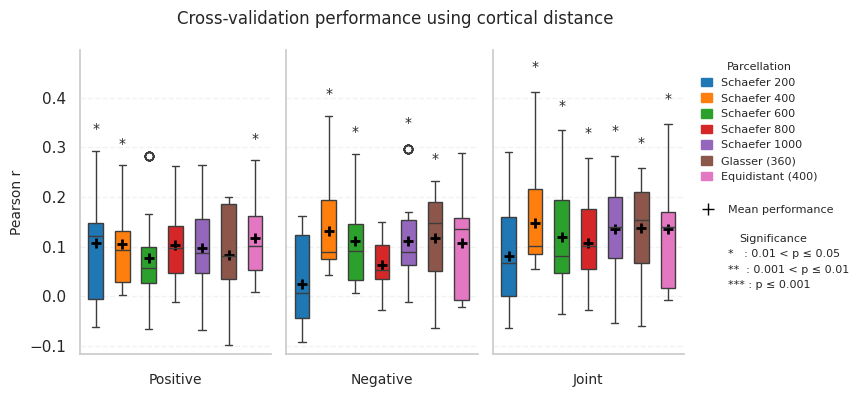

In [46]:
plot_models(long_df_dist,correct_p_vals(pvals),'Cross-validation performance using cortical distance',f'{odir}/distance_multiatlas')

In [ ]:
FCSES200,FCSES200_obs=get_r_p('<path to>/FC/Schaefer200/Reading_SES_FC_cpm_analysis/')
FCSES400,FCSES400_obs=get_r_p('<path to>/FC/Schaefer400/Reading_SES_FC_cpm_analysis/')
FCSES600,FCSES600_obs=get_r_p('<path to>/FC/Schaefer600/Reading_SES_FC_cpm_analysis/')
FCSES800,FCSES800_obs=get_r_p('<path to>/FC/Schaefer800/Reading_SES_FC_cpm_analysis/')
FCSES1000,FCSES1000_obs=get_r_p('<path to>/FC/Schaefer1000/Reading_SES_FC_cpm_analysis/')
Glasser_fc,Glasser_obs_fc=get_r_p('/<path to>/FC/Glasser//Reading_SES_FC_cpm_analysis/')
rand_eq_fc,rand_eq_obs_fc=get_r_p('<path to>/FC/randomEquidistant/Reading_SES_FC_cpm_analysis/')

/well/margulies/projects/DistanceValidation/data/HCP/FC/Schaefer200/Reading_SES_FC_cpm_analysis/
1000
/well/margulies/projects/DistanceValidation/data/HCP/FC/Schaefer400/Reading_SES_FC_cpm_analysis/
1000
/well/margulies/projects/DistanceValidation/data/HCP/FC/Schaefer600/Reading_SES_FC_cpm_analysis/
1000
/well/margulies/projects/DistanceValidation/data/HCP/FC/Schaefer800/Reading_SES_FC_cpm_analysis/
1000
/well/margulies/projects/DistanceValidation/data/HCP/FC/Schaefer1000/Reading_SES_FC_cpm_analysis/
1000
/well/margulies/projects/DistanceValidation/data/HCP/FC/Glasser//Reading_SES_FC_cpm_analysis/
1000
/well/margulies/projects/DistanceValidation/data/HCP/FC/randomEquidistant/Reading_SES_FC_cpm_analysis/
1000


In [48]:
parcel_list=['Schaefer 200','Schaefer 400','Schaefer 600','Schaefer 800','Schaefer 1000','Glasser (360)','Equidistant (400)']
data_list_fc=[FCSES200_obs,FCSES400_obs,FCSES600_obs,FCSES800_obs,FCSES1000_obs,Glasser_obs_fc,rand_eq_obs_fc]
stats_list_fc=[FCSES200, FCSES400, FCSES600, FCSES800, FCSES1000, Glasser_fc,rand_eq_fc ]

Positive model p-values
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Schaefer 200 vs. Schaefer 200: Custom statistical test, P_val:1.575e-02
Schaefer 400 vs. Schaefer 400: Custom statistical test, P_val:2.310e-02
Schaefer 600 vs. Schaefer 600: Custom statistical test, P_val:3.780e-02
Schaefer 800 vs. Schaefer 800: Custom statistical test, P_val:3.675e-02
Schaefer 1000 vs. Schaefer 1000: Custom statistical test, P_val:1.575e-02
Glasser (360) vs. Glasser (360): Custom statistical test, P_val:2.482e-02
Equidistant (400) vs. Equidistant (400): Custom statistical test, P_val:3.780e-02
Negative model p-values
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Schaefer 400 vs. Schaefer 400: Custom statistical 

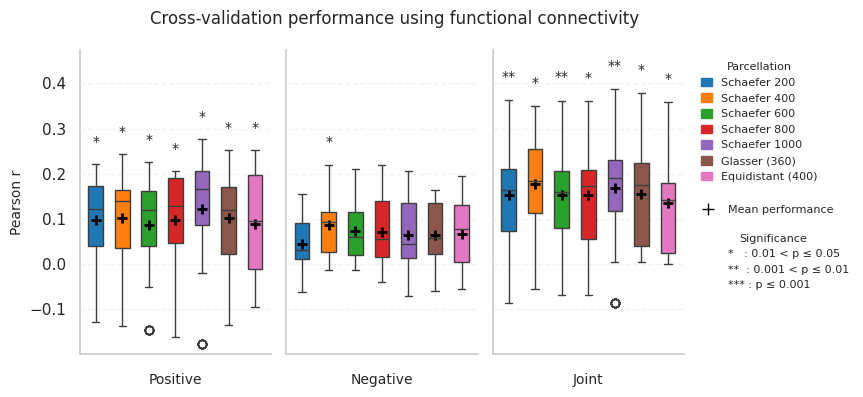

In [49]:
long_df_FC,pvals,rvals=prep_4_plotting(parcel_list,data_list_fc,stats_list_fc,model_type='top')
plot_models(long_df_FC,correct_p_vals(pvals),'Cross-validation performance using functional connectivity',f'{odir}/FC_multiatlas')

In [ ]:
SASES200,SASES200_obs=get_r_p('<path to>/SurfaceArea//Schaefer200/Reading_SES_SurfaceArea_cpm_analysis/')
SASES400,SASES400_obs=get_r_p('<path to>//SurfaceArea/Schaefer400/Reading_SES_SurfaceArea_cpm_analysis/')
SASES600,SASES600_obs=get_r_p('<path to>//SurfaceArea/Schaefer600/Reading_SES_SurfaceArea_cpm_analysis/')
SASES800,SASES800_obs=get_r_p('/<path to>//SurfaceArea/Schaefer800/Reading_SES_SurfaceArea_cpm_analysis/')
SASES1000,SASES1000_obs=get_r_p('<path to>//SurfaceArea/Schaefer1000/Reading_SES_SurfaceArea_cpm_analysis/')
Glasser_sa,Glasser_obs_sa=get_r_p('<path to>//SurfaceArea/Glasser/Reading_SES_SurfaceArea_cpm_analysis/')
rand_eq_sa,rand_eq_obs_sa=get_r_p('<path to>//SurfaceArea/randomEquidistant/Reading_SES_SurfaceArea_cpm_analysis/')

/well/margulies/projects/DistanceValidation/data/HCP/SurfaceArea//Schaefer200/Reading_SES_SurfaceArea_cpm_analysis/
1000
/well/margulies/projects/DistanceValidation/data/HCP/SurfaceArea/Schaefer400/Reading_SES_SurfaceArea_cpm_analysis/
1000
/well/margulies/projects/DistanceValidation/data/HCP/SurfaceArea/Schaefer600/Reading_SES_SurfaceArea_cpm_analysis/
1000
/well/margulies/projects/DistanceValidation/data/HCP/SurfaceArea/Schaefer800/Reading_SES_SurfaceArea_cpm_analysis/
1000
/well/margulies/projects/DistanceValidation/data/HCP/SurfaceArea/Schaefer1000/Reading_SES_SurfaceArea_cpm_analysis/
1000
/well/margulies/projects/DistanceValidation/data/HCP/SurfaceArea/Glasser/Reading_SES_SurfaceArea_cpm_analysis/
1000
/well/margulies/projects/DistanceValidation/data/HCP/SurfaceArea/randomEquidistant/Reading_SES_SurfaceArea_cpm_analysis/
1000


In [51]:
parcel_list=['Schaefer 200','Schaefer 400','Schaefer 600','Schaefer 800','Schaefer 1000','Glasser (360)','Equidistant (400)']
data_list_sa=[SASES200_obs,SASES400_obs,SASES600_obs,SASES800_obs,SASES1000_obs,Glasser_obs_sa,rand_eq_obs_sa]
stats_list_sa=[SASES200, SASES400, SASES600, SASES800, SASES1000, Glasser_sa,rand_eq_sa ]

Positive model p-values
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Schaefer 200 vs. Schaefer 200: Custom statistical test, P_val:5.250e-03
Schaefer 400 vs. Schaefer 400: Custom statistical test, P_val:1.633e-02
Schaefer 600 vs. Schaefer 600: Custom statistical test, P_val:1.633e-02
Schaefer 800 vs. Schaefer 800: Custom statistical test, P_val:5.250e-03
Schaefer 1000 vs. Schaefer 1000: Custom statistical test, P_val:3.600e-02
Glasser (360) vs. Glasser (360): Custom statistical test, P_val:5.250e-03
Equidistant (400) vs. Equidistant (400): Custom statistical test, P_val:2.275e-02
Negative model p-values
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Schaefer 800 vs. Schaefer 800: Custom statistical 

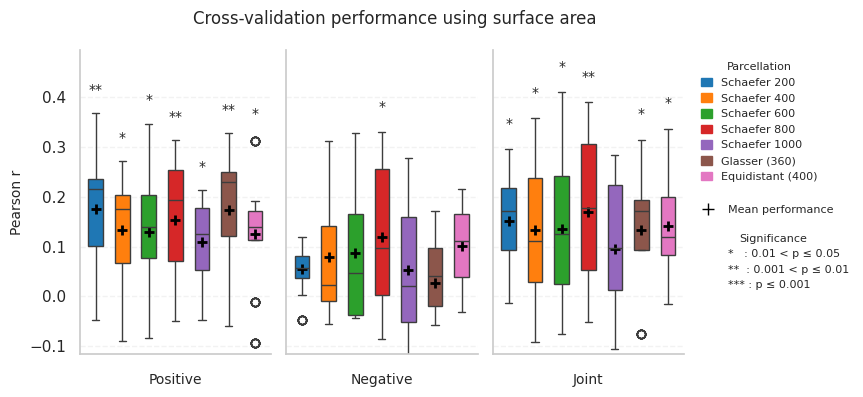

In [52]:
long_df_sa,pvals,rvals=prep_4_plotting(parcel_list,data_list_sa,stats_list_sa,model_type='top')
plot_models(long_df_sa,correct_p_vals(pvals),'Cross-validation performance using surface area',f'{odir}/surface_area_multiatlas')

In [81]:
out = (
    long_df_sa
    .groupby(["Atlas", "Model"], observed=True, as_index=False)
    .agg(mean=("Value", "mean"))
)


In [38]:
def significance_test(result1, result2, tries=10_000, random_state=41):
    benchmark = np.abs(result1.mean() - result2.mean())  # observed difference

    if random_state is not None:
        np.random.seed(random_state)  # fixing seed for reproducability
    samples = np.zeros(tries)  # the distribution of differences
    for i in range(tries):
        msk = np.random.random(size=result1.shape[0]) < 0.5


        result1_perm = result1.copy()
        result2_perm = result2.copy()

        result1_perm[msk] = result2[msk]
        result2_perm[msk] = result1[msk]
        samples[i]=np.abs(result1_perm.mean()-result2_perm.mean())


    pvalue = (np.sum(samples >= benchmark) + 1) / (tries + 1)


    return pvalue

In [147]:
plt.rcParams["font.family"] = "Arial"

In [167]:
def plot_pairwise_boxes(all_v_top50, title=""):
    """
    all_v_top50: dict mapping parcel_name -> DataFrame with two numeric columns (e.g. 'joint_full','joint_top')
    """
    ### get pvalues 
    p_vals=[]
    for i in all_v_top50:
        dat=all_v_top50[i]
        p=significance_test(dat['joint_full'].values.ravel(),dat['joint_top'].values.ravel())
        p_vals.append(p)
    corr_p=multipletests(p_vals,method='bonferroni')
    corr_p=corr_p[1]

    # Build long-form DataFrame
    rows = []
    for parcel, df in all_v_top50.items():
        cols = list(df.columns[:2])  # first two columns
        for col in cols:
            vals = df[col].dropna().astype(float).values
            rows.extend([{"Parcel": parcel, "Type": col, "Value": float(v)} for v in vals])
    long = pd.DataFrame(rows)
    if long.empty:
        raise ValueError("No data to plot (long-form DataFrame is empty).")
    long["Type"] = long["Type"].map({"joint_full": "all",
                                 "joint_top": "top 50"})

    # Plotting prep
    sns.set_theme(style="whitegrid", rc={"font.size":10, "axes.titlesize":11, "axes.labelsize":10})
    parcels = list(all_v_top50.keys())

    
    types = list(long["Type"].unique())
    fig_width = max(6, len(parcels) * 0.6)
    fig, ax = plt.subplots(figsize=(8, 4))

    # boxplot: subtle colors, thin lines
    # box_palette = sns.color_palette("husl", n_colors=len(types))
    box_palette = ["#6A0DAD",  # deep purple
               "#B19CD9"]  # light lavender

    sns.boxplot(
        data=long, x="Parcel", y="Value", hue="Type",
        order=parcels, hue_order=types, width=0.6, dodge=True,
        palette=box_palette, saturation=0.75, linewidth=0.4, ax=ax
    )

    ### point plot for mean 
    black_palette = {t: "black" for t in types}
    sns.pointplot(
        data=long, x="Parcel", y="Value", hue="Type",
        order=parcels, hue_order=types,
        estimator=np.mean, errorbar=None, dodge=0.3,
        markers="+", linestyles="", markersize=6, palette=black_palette, ax=ax)
    
    
    
    ### annotate plot
    pairs = [((p, "all"), (p, "top 50")) for p in parcels]
    annot = Annotator(ax, pairs, data=long, x="Parcel", y="Value", hue="Type", order=parcels, hue_order=types)
    annot.configure(test=None, text_format="star", loc="inside", line_offset=0.02, hide_non_significant=True)
    annot.set_pvalues_and_annotate([float(p) for p in corr_p])

    
    
    
    # Tidy axis and legend: keep only one legend (the boxplot legend)
    # pointplot creates a second legend — remove duplicates and keep the first (boxplot) legend
    handles, labels = ax.get_legend_handles_labels()
    # keep first len(types) handles/labels (boxplot legend comes first)
 
    ax.legend(handles[:len(types)], labels[:len(types)], title="Features included",
                  fontsize=7, title_fontsize=7, frameon=False, loc="upper right",bbox_to_anchor=(1.2, 0.70))

    legend_fontsize=7
    # ---- Mean Performance Legend ----
    mean_handle = plt.Line2D(
        [0],[0],marker='+',color='black',
        linestyle='None',markersize=8
    )
    
    fig.legend(
        handles=[mean_handle], labels=["Mean performance"],
        title="",
        loc="center left", bbox_to_anchor=(0.865, 0.48),
        frameon=False, prop={'size':legend_fontsize},
        title_fontsize=legend_fontsize
    )
    
    # ---- Significance Legend ----
    sig_handles = [
        plt.Line2D([0],[0],color='black',linestyle='None',label="*   : 0.01 < p ≤ 0.05"),
        plt.Line2D([0],[0],color='black',linestyle='None',label="**  : 0.001 < p ≤ 0.01"),
        plt.Line2D([0],[0],color='black',linestyle='None',label="*** : p ≤ 0.001")
    ]
    
    fig.legend(
        handles=sig_handles,
        title="Significance",
        loc="center left", bbox_to_anchor=(0.84, 0.35),
        frameon=False, prop={'size':legend_fontsize},
        title_fontsize=legend_fontsize
    )
     
    # Aesthetics
    ax.set_xlabel("")
    ax.set_ylabel("Pearson r")
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")   # fixes FixedFormatter warning
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    sns.despine()
    # tighten, return fig+ax for further manipulation or saving
    plt.tight_layout()
    return fig, ax

In [168]:
data_list_dist=[dist200_obs,dist400_obs,dist600_obs,dist800_obs,dist1000_obs,Glasser_obs_dist,rand_eq_obs_dist]
data_list_FC=[FCSES200_obs,FCSES400_obs,FCSES600_obs,FCSES800_obs,FCSES1000_obs,Glasser_obs_fc,rand_eq_obs_fc]
parcel_list=['Schaefer 200','Schaefer 400','Schaefer 600','Schaefer 800','Schaefer 1000','Glasser (360)','Equidistant (400)']
all_v_top50_dist={}
all_v_top50_fc={}
for i,j in enumerate(parcel_list):
    all_v_top50_dist[j]=data_list_dist[i].iloc[:, [0, 3]]
    all_v_top50_fc[j]=data_list_FC[i].iloc[:, [0, 3]]

In [169]:
from statsmodels.stats.multitest import multipletests

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Schaefer 400_all vs. Schaefer 400_top 50: Custom statistical test, P_val:6.999e-04
Schaefer 200_all vs. Schaefer 200_top 50: Custom statistical test, P_val:6.999e-04
Schaefer 800_all vs. Schaefer 800_top 50: Custom statistical test, P_val:3.990e-02
Schaefer 1000_all vs. Schaefer 1000_top 50: Custom statistical test, P_val:6.999e-04
Glasser (360)_all vs. Glasser (360)_top 50: Custom statistical test, P_val:6.999e-04


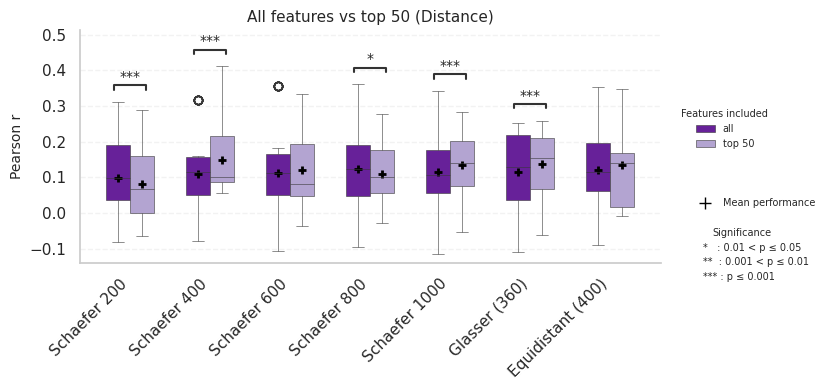

In [170]:
fig, ax = plot_pairwise_boxes(all_v_top50_dist, title="All features vs top 50 (Distance)")
fig.savefig(f"{odir}/fullvtop_dist.png", dpi=600, bbox_inches="tight")

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Schaefer 400_all vs. Schaefer 400_top 50: Custom statistical test, P_val:6.999e-04
Schaefer 200_all vs. Schaefer 200_top 50: Custom statistical test, P_val:1.400e-03
Schaefer 1000_all vs. Schaefer 1000_top 50: Custom statistical test, P_val:6.299e-03
Equidistant (400)_all vs. Equidistant (400)_top 50: Custom statistical test, P_val:9.099e-03


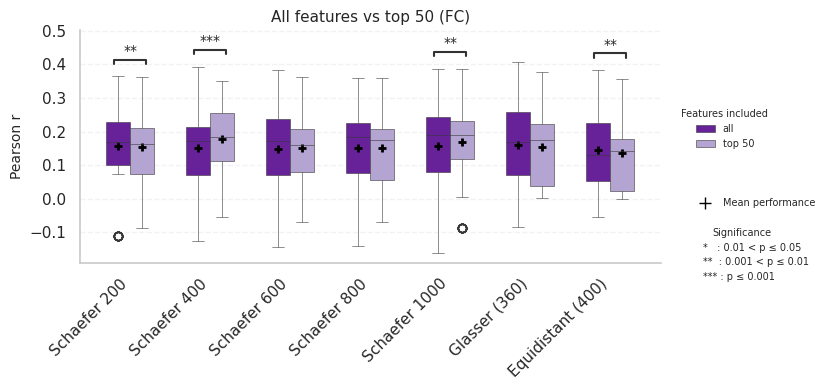

In [171]:
fig, ax = plot_pairwise_boxes(all_v_top50_fc, title="All features vs top 50 (FC)")
fig.savefig(f"{odir}/fullvtop_FC.png", dpi=600, bbox_inches="tight")